<a href="https://colab.research.google.com/github/HamishjHartley/CS547/blob/Asssignment-2/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: deap in c:\users\theha\appdata\local\programs\python\python310\lib\site-packages (1.4.1)



c:\Users\theha\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMulti' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\theha\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg            	std                      	min        	max        
0  	100   	[  5.97 300.15]	[ 0.29849623 28.49609622]	[  3. 220.]	[  6. 361.]
1  	92    	[  5.97 277.79]	[ 0.29849623 16.15691493]	[  3. 220.]	[  6. 299.]
2  	88    	[  6.   261.06]	[ 0.        14.6313499]  	[  6. 217.]	[  6. 280.]
3  	88    	[  5.97 246.55]	[ 0.29849623 14.13745027]	[  3. 197.]	[  6. 263.]
4  	88    	[  5.94 230.08]	[ 0.42       15.07692276]	[  3. 178.]	[  6. 250.]
5  	92    	[  5.94 217.08]	[ 0.42       10.17023107]	[  3. 178.]	[  6. 230.]
6  	89    	[  5.94 205.8 ]	[ 0.42      13.8014492]  	[  3. 153.]	[  6. 220.]
7  	87    	[  5.97 192.5 ]	[ 0.29849623 15.44894818]	[  3. 141.]	[  6. 208.]
8  	91    	[  5.97 179.28]	[ 0.29849623 14.85266306]	[  3. 139.]	[  6. 199.]
9  	91    	[  5.94 164.04]	[ 0.42       11.81771552]	[  3. 128.]	[  6. 180.]
10 	90    	[  5.97 151.26]	[ 0.29849623 12.63378012]	[  3. 109.]	[  6. 165.]
11 	86    	[  5.94 141.65]	[ 0.42      13.8292263]  	[  3. 101.]	[  6. 158.]

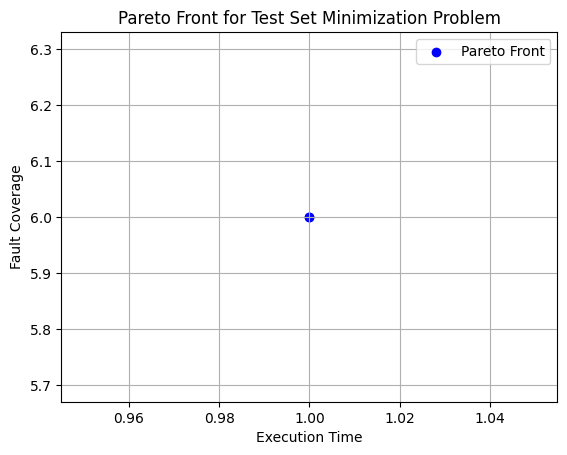

In [3]:
%pip install deap
import random
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms

# Load the dataset
data = pd.read_csv('C:/Users/theha/OneDrive/Documents/repos/CS547/smallfaultmatrixplustime.txt', header=None)
fault_matrix = data.iloc[:, 1:-1].values  # Binary fault matrix
execution_time = data.iloc[:, -1].values  # Execution times for each test

# GA Setup
NUM_TESTS = 100  # Total number of tests

# Define objectives to maximize fault coverage and minimize execution time
# NSGA-II requires objectives to be minimized, so we'll use negative fault coverage
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# Initialize DEAP toolbox
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, NUM_TESTS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function
def evaluate(individual):
    selected_tests = np.where(individual)[0]  # Indices of selected tests
    if len(selected_tests) == 0:  # Avoid empty selection
        return 0, float('inf')

    # Calculate fault coverage (unique faults detected)
    selected_fault_matrix = fault_matrix[selected_tests, :]
    fault_coverage = np.sum(np.any(selected_fault_matrix, axis=0))

    # Total execution time of selected tests
    total_time = np.sum(execution_time[selected_tests])

    # Return fault coverage (maximized) and execution time (minimized)
    return fault_coverage, total_time

# Register GA operations in toolbox
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selNSGA2)
toolbox.register("map", map)

# GA Parameters
POP_SIZE = 100
NGEN = 50
CXPB, MUTPB = 0.7, 0.2

def main():
    random.seed(42)

    # Create initial population
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.ParetoFront()

    # Statistics for logging
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean, axis=0)
    stats.register("std", np.std, axis=0)
    stats.register("min", np.min, axis=0)
    stats.register("max", np.max, axis=0)

    # Run the algorithm
    pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, mu=POP_SIZE, lambda_=POP_SIZE, cxpb=CXPB, mutpb=MUTPB,
                                             ngen=NGEN, stats=stats, halloffame=hof, verbose=True)

    return pop, logbook, hof

# Run the GA
if __name__ == "__main__":
    pop, logbook, pareto_front = main()

    # Display Pareto front solutions
    print("Pareto front solutions:")
    for ind in pareto_front:
        fault_coverage, exec_time = ind.fitness.values
        print(f"Fault Coverage: {fault_coverage}, Execution Time: {exec_time}")

    # Visualization
    import matplotlib.pyplot as plt

    # Plotting the Pareto front
    pareto_coverage = [ind.fitness.values[0] for ind in pareto_front]
    pareto_time = [ind.fitness.values[1] for ind in pareto_front]

    plt.scatter(pareto_time, pareto_coverage, c="blue", label="Pareto Front")
    plt.xlabel("Execution Time")
    plt.ylabel("Fault Coverage")
    plt.title("Pareto Front for Test Set Minimization Problem")
    plt.legend()
    plt.grid()
    plt.show()


/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMulti' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg            	std                      	min        	max        
0  	50    	[  6.   300.22]	[ 0.         27.16489647]	[  6. 251.]	[  6. 358.]
1  	33    	[  6.   277.98]	[ 0.         16.23143863]	[  6. 232.]	[  6. 302.]
2  	32    	[  6.  262.9]  	[ 0.         11.98707637]	[  6. 232.]	[  6. 280.]
3  	38    	[  6.   253.82]	[0.         9.57640851]  	[  6. 232.]	[  6. 266.]
4  	36    	[  6.   240.48]	[ 0.        11.0638872]  	[  6. 201.]	[  6. 253.]
5  	37    	[  6.   230.46]	[ 0.        12.1411861]  	[  6. 201.]	[  6. 241.]
6  	32    	[  6. 219.]    	[ 0.         13.01998464]	[  6. 183.]	[  6. 235.]
7  	36    	[  6.   205.38]	[ 0.         10.81645043]	[  6. 183.]	[  6. 222.]
8  	35    	[  6.   192.18]	[ 0.         12.83852016]	[  6. 144.]	[  6. 204.]
9  	38    	[  6.   180.18]	[ 0.         13.65970717]	[  6. 144.]	[  6. 194.]
10 	32    	[  5.94 172.78]	[ 0.42       12.54318939]	[  3. 144.]	[  6. 187.]
11 	39    	[  5.88 164.26]	[0.58787754 9.56412045]  	[  3. 143.]	[  6. 176.]

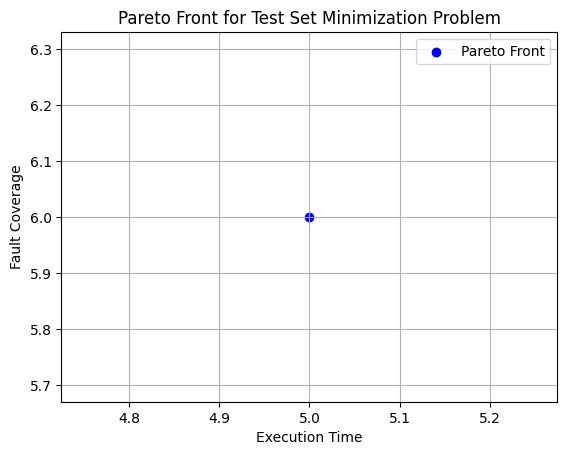

In [3]:
!pip install deap
import random
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms

# Load the dataset
data = pd.read_csv('/smallfaultmatrixplustime.txt', header=None)
fault_matrix = data.iloc[:, 1:-1].values  # Binary fault matrix
execution_time = data.iloc[:, -1].values  # Execution times for each test

# GA Setup
NUM_TESTS = 100  # Total number of tests

# Define objectives to maximize fault coverage and minimize execution time
# NSGA-II requires objectives to be minimized, so we'll use negative fault coverage
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# Initialize DEAP toolbox
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, NUM_TESTS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function
def evaluate(individual):
    selected_tests = np.where(individual)[0]  # Indices of selected tests
    if len(selected_tests) == 0:  # Avoid empty selection
        return 0, float('inf')

    # Calculate fault coverage (unique faults detected)
    selected_fault_matrix = fault_matrix[selected_tests, :]
    fault_coverage = np.sum(np.any(selected_fault_matrix, axis=0))

    # Total execution time of selected tests
    total_time = np.sum(execution_time[selected_tests])

    # Return fault coverage (maximized) and execution time (minimized)
    return fault_coverage, total_time

# Register GA operations in toolbox
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selNSGA2)
toolbox.register("map", map)

# GA Parameters
POP_SIZE = 50
NGEN = 50
CXPB, MUTPB = 0.5, 0.2

def main():
    random.seed(42)

    # Create initial population
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.ParetoFront()

    # Statistics for logging
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean, axis=0)
    stats.register("std", np.std, axis=0)
    stats.register("min", np.min, axis=0)
    stats.register("max", np.max, axis=0)

    # Run the algorithm
    pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, mu=POP_SIZE, lambda_=POP_SIZE, cxpb=CXPB, mutpb=MUTPB,
                                             ngen=NGEN, stats=stats, halloffame=hof, verbose=True)

    return pop, logbook, hof

# Run the GA
if __name__ == "__main__":
    pop, logbook, pareto_front = main()

    # Display Pareto front solutions
    print("Pareto front solutions:")
    for ind in pareto_front:
        fault_coverage, exec_time = ind.fitness.values
        print(f"Fault Coverage: {fault_coverage}, Execution Time: {exec_time}")

    # Visualization
    import matplotlib.pyplot as plt

    # Plotting the Pareto front
    pareto_coverage = [ind.fitness.values[0] for ind in pareto_front]
    pareto_time = [ind.fitness.values[1] for ind in pareto_front]

    plt.scatter(pareto_time, pareto_coverage, c="blue", label="Pareto Front")
    plt.xlabel("Execution Time")
    plt.ylabel("Fault Coverage")
    plt.title("Pareto Front for Test Set Minimization Problem")
    plt.legend()
    plt.grid()
    plt.show()


Note: you may need to restart the kernel to use updated packages.
gen	nevals	avg            	std                      	min        	max        
0  	100   	[  5.97 300.15]	[ 0.29849623 28.49609622]	[  3. 220.]	[  6. 361.]
1  	92    	[  5.97 277.79]	[ 0.29849623 16.15691493]	[  3. 220.]	[  6. 299.]
2  	88    	[  6.   261.06]	[ 0.        14.6313499]  	[  6. 217.]	[  6. 280.]
3  	88    	[  5.97 246.55]	[ 0.29849623 14.13745027]	[  3. 197.]	[  6. 263.]



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\theha\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMulti' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\theha\AppData\Local\Programs\Python\Python310\lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


4  	88    	[  5.94 230.08]	[ 0.42       15.07692276]	[  3. 178.]	[  6. 250.]
5  	92    	[  5.94 217.08]	[ 0.42       10.17023107]	[  3. 178.]	[  6. 230.]
6  	89    	[  5.94 205.8 ]	[ 0.42      13.8014492]  	[  3. 153.]	[  6. 220.]
7  	87    	[  5.97 192.5 ]	[ 0.29849623 15.44894818]	[  3. 141.]	[  6. 208.]
8  	91    	[  5.97 179.28]	[ 0.29849623 14.85266306]	[  3. 139.]	[  6. 199.]
9  	91    	[  5.94 164.04]	[ 0.42       11.81771552]	[  3. 128.]	[  6. 180.]
10 	90    	[  5.97 151.26]	[ 0.29849623 12.63378012]	[  3. 109.]	[  6. 165.]
11 	86    	[  5.94 141.65]	[ 0.42      13.8292263]  	[  3. 101.]	[  6. 158.]
12 	92    	[  5.94 127.59]	[ 0.42       14.45689801]	[ 3. 61.]  	[  6. 143.]
13 	82    	[  5.88 115.48]	[ 0.58787754 12.92940834]	[ 3. 58.]  	[  6. 130.]
14 	90    	[  5.85 104.98]	[ 0.65383484 14.97129253]	[ 3. 49.]  	[  6. 120.]
15 	89    	[ 5.96 94.74]  	[ 0.39799497 14.3168572 ]	[ 2. 49.]  	[  6. 110.]
16 	90    	[ 5.97 85.35]  	[ 0.29849623 11.46854394]	[ 3. 49.]  	[ 6. 99.]  

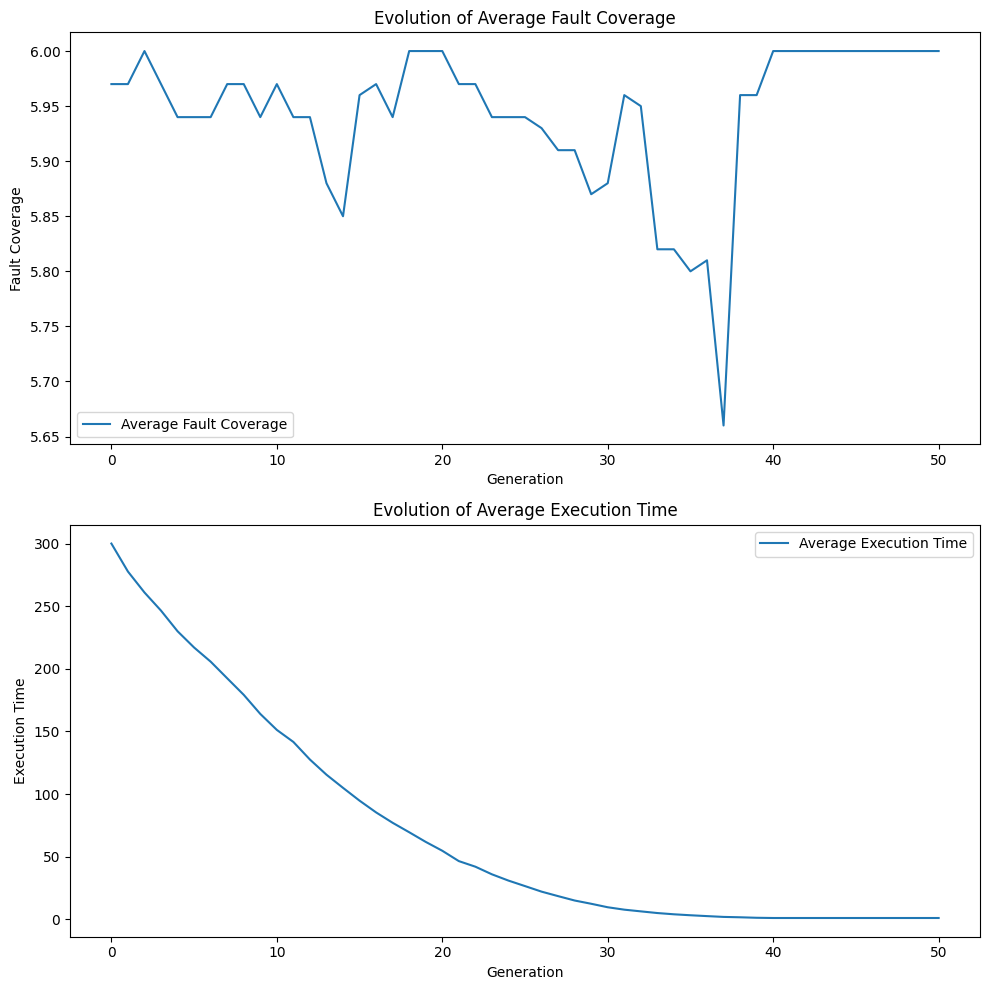

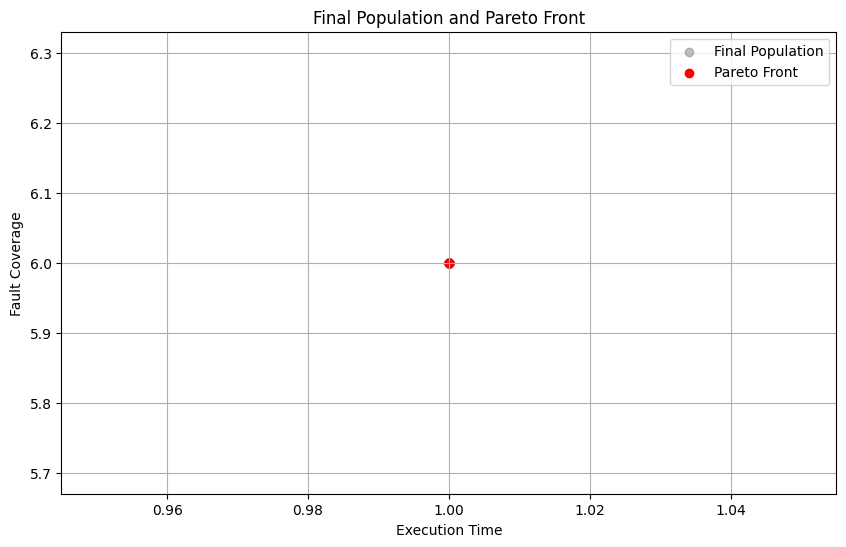

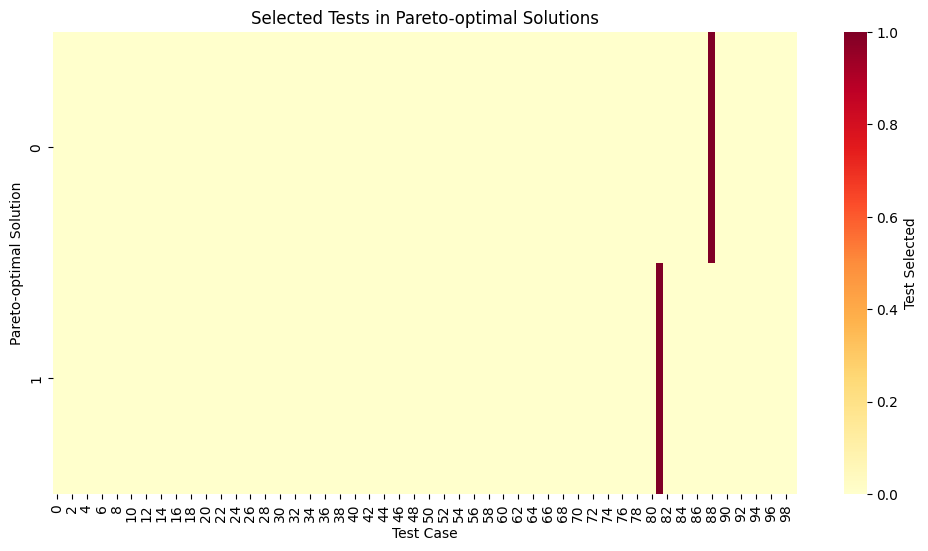

In [6]:
import random
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import seaborn as sns

%pip install deap
import random
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms

# Load the dataset
data = pd.read_csv('C:/Users/theha/OneDrive/Documents/repos/CS547/smallfaultmatrixplustime.txt', header=None)
fault_matrix = data.iloc[:, 1:-1].values  # Binary fault matrix
execution_time = data.iloc[:, -1].values  # Execution times for each test

# GA Setup
NUM_TESTS = 100  # Total number of tests

# Define objectives to maximize fault coverage and minimize execution time
# NSGA-II requires objectives to be minimized, so we'll use negative fault coverage
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# Initialize DEAP toolbox
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, NUM_TESTS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function
def evaluate(individual):
    selected_tests = np.where(individual)[0]  # Indices of selected tests
    if len(selected_tests) == 0:  # Avoid empty selection
        return 0, float('inf')

    # Calculate fault coverage (unique faults detected)
    selected_fault_matrix = fault_matrix[selected_tests, :]
    fault_coverage = np.sum(np.any(selected_fault_matrix, axis=0))

    # Total execution time of selected tests
    total_time = np.sum(execution_time[selected_tests])

    # Return fault coverage (maximized) and execution time (minimized)
    return fault_coverage, total_time

# Register GA operations in toolbox
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selNSGA2)
toolbox.register("map", map)

# GA Parameters
POP_SIZE = 100
NGEN = 50
CXPB, MUTPB = 0.7, 0.2

def main():
    random.seed(42)

    # Create initial population
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.ParetoFront()

    # Statistics for logging
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean, axis=0)
    stats.register("std", np.std, axis=0)
    stats.register("min", np.min, axis=0)
    stats.register("max", np.max, axis=0)

    # Run the algorithm
    pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, mu=POP_SIZE, lambda_=POP_SIZE, cxpb=CXPB, mutpb=MUTPB,
                                             ngen=NGEN, stats=stats, halloffame=hof, verbose=True)

    return pop, logbook, hof

# Run the GA
if __name__ == "__main__":
    pop, logbook, pareto_front = main()

    # Display Pareto front solutions
    print("Pareto front solutions:")
    for ind in pareto_front:
        fault_coverage, exec_time = ind.fitness.values
        print(f"Fault Coverage: {fault_coverage}, Execution Time: {exec_time}")

    # Visualization 1: Evolution of population over generations
    gen = logbook.select("gen")
    avg_coverage = [values[0] for values in logbook.select("avg")]
    avg_time = [values[1] for values in logbook.select("avg")]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    ax1.plot(gen, avg_coverage, label="Average Fault Coverage")
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fault Coverage")
    ax1.legend()
    ax1.set_title("Evolution of Average Fault Coverage")

    ax2.plot(gen, avg_time, label="Average Execution Time")
    ax2.set_xlabel("Generation")
    ax2.set_ylabel("Execution Time")
    ax2.legend()
    ax2.set_title("Evolution of Average Execution Time")

    plt.tight_layout()
    plt.show()

    # Visualization 2: Final population and Pareto front
    pop_coverage = [ind.fitness.values[0] for ind in pop]
    pop_time = [ind.fitness.values[1] for ind in pop]
    pareto_coverage = [ind.fitness.values[0] for ind in pareto_front]
    pareto_time = [ind.fitness.values[1] for ind in pareto_front]

    plt.figure(figsize=(10, 6))
    plt.scatter(pop_time, pop_coverage, c="gray", alpha=0.5, label="Final Population")
    plt.scatter(pareto_time, pareto_coverage, c="red", label="Pareto Front")
    plt.xlabel("Execution Time")
    plt.ylabel("Fault Coverage")
    plt.title("Final Population and Pareto Front")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Visualization 3: Heatmap of selected tests for Pareto-optimal solutions
    pareto_solutions = np.array([ind for ind in pareto_front])
    plt.figure(figsize=(12, 6))
    sns.heatmap(pareto_solutions, cmap="YlOrRd", cbar_kws={'label': 'Test Selected'})
    plt.xlabel("Test Case")
    plt.ylabel("Pareto-optimal Solution")
    plt.title("Selected Tests in Pareto-optimal Solutions")
    plt.show()


/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMulti' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	avg            	std                      	min        	max        
0  	100   	[ 20.33 717.97]	[ 2.50221902 71.88789258]	[ 14. 476.]	[ 26. 868.]
1  	84    	[ 21.14 680.26]	[ 2.73868582 80.28046089]	[ 15. 476.]	[ 26. 906.]
2  	83    	[ 21.45 639.22]	[ 2.81202774 74.89947663]	[ 15. 476.]	[ 26. 885.]
3  	74    	[ 21.52 599.  ]	[ 2.98154322 67.35547491]	[ 15. 411.]	[ 26. 716.]
4  	78    	[ 21.37 566.23]	[ 3.27919197 72.95558306]	[ 15. 411.]	[ 26. 693.]
5  	83    	[ 21.49 543.17]	[ 3.4510723  76.22900432]	[ 14. 400.]	[ 26. 693.]
6  	76    	[ 21.25 510.88]	[ 3.22916398 68.51690011]	[ 14. 329.]	[ 26. 650.]
7  	77    	[ 21.64 491.96]	[ 3.18596924 67.69592602]	[ 14. 329.]	[ 26. 634.]
8  	74    	[ 21.94 474.1 ]	[ 3.06535479 62.49936   ]	[ 14. 329.]	[ 26. 614.]
9  	85    	[ 21.33 450.93]	[ 3.41483528 62.73328542]	[ 14. 329.]	[ 26. 614.]
10 	72    	[ 21.74 438.5 ]	[ 3.51744225 68.37843227]	[ 14. 316.]	[ 26. 566.]
11 	86    	[ 20.84 407.35]	[ 3.45462009 53.7751569 ]	[ 14. 285.]	[ 26. 534.]

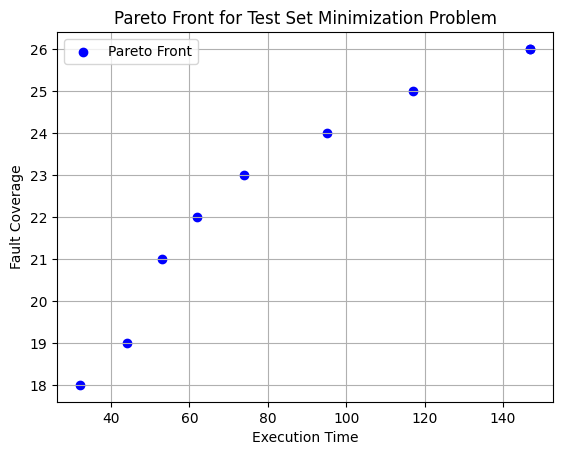

In [ ]:
!pip install deap
import random
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms

# Load the dataset
data = pd.read_csv('/content/bigfaultmatrixplustime.txt', header=None)
fault_matrix = data.iloc[:, 1:-1].values  # Binary fault matrix
execution_time = data.iloc[:, -1].values  # Execution times for each test

# GA Setup
NUM_TESTS = 100  # Total number of tests

# Define objectives to maximize fault coverage and minimize execution time
# NSGA-II requires objectives to be minimized, so we'll use negative fault coverage
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# Initialize DEAP toolbox
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, NUM_TESTS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function
def evaluate(individual):
    selected_tests = np.where(individual)[0]  # Indices of selected tests
    if len(selected_tests) == 0:  # Avoid empty selection
        return 0, float('inf')

    # Calculate fault coverage (unique faults detected)
    selected_fault_matrix = fault_matrix[selected_tests, :]
    fault_coverage = np.sum(np.any(selected_fault_matrix, axis=0))

    # Total execution time of selected tests
    total_time = np.sum(execution_time[selected_tests])

    # Return fault coverage (maximized) and execution time (minimized)
    return fault_coverage, total_time

# Register GA operations in toolbox
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selNSGA2)
toolbox.register("map", map)

# GA Parameters
POP_SIZE = 100
NGEN = 50
CXPB, MUTPB = 0.5, 0.3

def main():
    random.seed(42)

    # Create initial population
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.ParetoFront()

    # Statistics for logging
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean, axis=0)
    stats.register("std", np.std, axis=0)
    stats.register("min", np.min, axis=0)
    stats.register("max", np.max, axis=0)

    # Run the algorithm
    pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, mu=POP_SIZE, lambda_=POP_SIZE, cxpb=CXPB, mutpb=MUTPB,
                                             ngen=NGEN, stats=stats, halloffame=hof, verbose=True)

    return pop, logbook, hof

# Run the GA
if __name__ == "__main__":
    pop, logbook, pareto_front = main()

    # Display Pareto front solutions
    print("Pareto front solutions:")
    for ind in pareto_front:
        fault_coverage, exec_time = ind.fitness.values
        print(f"Fault Coverage: {fault_coverage}, Execution Time: {exec_time}")

    # Visualization
    import matplotlib.pyplot as plt

    # Plotting the Pareto front
    pareto_coverage = [ind.fitness.values[0] for ind in pareto_front]
    pareto_time = [ind.fitness.values[1] for ind in pareto_front]

    plt.scatter(pareto_time, pareto_coverage, c="blue", label="Pareto Front")
    plt.xlabel("Execution Time")
    plt.ylabel("Fault Coverage")
    plt.title("Pareto Front for Test Set Minimization Problem")
    plt.legend()
    plt.grid()
    plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.4 MB/s eta 0:00:00
gen	nevals	avg            	std                      	min        	max        
0  	100   	[ 20.33 717.97]	[ 2.50221902 71.88789258]	[ 14. 476.]	[ 26. 868.]
1  	92    	[ 21.32 677.12]	[ 2.87012195 62.20567177]	[ 15. 476.]	[ 26. 838.]
2  	88    	[ 21.74 637.88]	[ 2.77351762 54.89176259]	[ 15. 460.]	[ 26. 731.]
3  	88    	[ 21.71 602.55]	[ 3.04399409 52.26267789]	[ 14. 460.]	[ 26. 714.]
4  	88    	[ 21.61 567.19]	[ 3.18086466 53.9806808 ]	[ 14. 417.]	[ 26. 728.]
5  	92    	[ 21.7  541.48]	[ 3.15119025 56.73155736]	[ 14. 404.]	[ 26. 693.]
6  	89    	[ 21.68 514.32]	[ 3.22142825 60.43358007]	[ 13. 343.]	[ 26. 665.]
7  	87    	[ 21.96 490.2 ]	[ 3.06241735 63.21060038]	[ 13. 343.]	[ 26. 639.]
8  	91    	[ 22.3 468.6]  	[ 3.04466747 62.23953727]	[ 13. 343.]	[ 26. 614.]
9  	91    	[ 22.13 439.01]	[ 3.12299536 63.40875255]	[ 13. 315.]	[ 26. 586.]
10 	90    	[ 22.14 411.78]	[ 3.34071849 54.78550538]	[ 13. 295.]	[ 26. 53

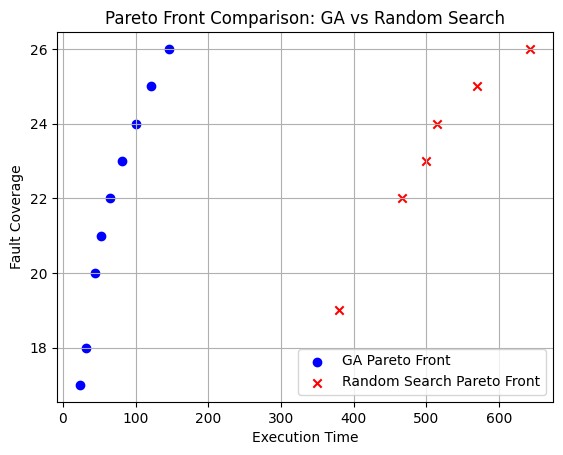

In [ ]:
# Install DEAP if necessary
!pip install deap

import random
import numpy as np
import pandas as pd
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('C:/Users/theha/OneDrive/Documents/repos/CS547/smallfaultmatrixplustime.txt', header=None)
fault_matrix = data.iloc[:, 1:-1].values  # Binary fault matrix
execution_time = data.iloc[:, -1].values  # Execution times for each test

# GA Setup
NUM_TESTS = 100  # Total number of tests

# Define objectives to maximize fault coverage and minimize execution time
# NSGA-II requires objectives to be minimized, so we'll use negative fault coverage
creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

# Initialize DEAP toolbox
toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, NUM_TESTS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Fitness function
def evaluate(individual):
    selected_tests = np.where(individual)[0]  # Indices of selected tests
    if len(selected_tests) == 0:  # Avoid empty selection
        return 0, float('inf')

    # Calculate fault coverage (unique faults detected)
    selected_fault_matrix = fault_matrix[selected_tests, :]
    fault_coverage = np.sum(np.any(selected_fault_matrix, axis=0))

    # Total execution time of selected tests
    total_time = np.sum(execution_time[selected_tests])

    # Return fault coverage (maximized) and execution time (minimized)
    return fault_coverage, total_time

# Register GA operations in toolbox
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selNSGA2)
toolbox.register("map", map)

# GA Parameters
POP_SIZE = 100
NGEN = 50
CXPB, MUTPB = 0.7, 0.2

def main():
    random.seed(42)

    # Create initial population
    pop = toolbox.population(n=POP_SIZE)
    hof = tools.ParetoFront()

    # Statistics for logging
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean, axis=0)
    stats.register("std", np.std, axis=0)
    stats.register("min", np.min, axis=0)
    stats.register("max", np.max, axis=0)

    # Run the algorithm
    pop, logbook = algorithms.eaMuPlusLambda(pop, toolbox, mu=POP_SIZE, lambda_=POP_SIZE, cxpb=CXPB, mutpb=MUTPB,
                                             ngen=NGEN, stats=stats, halloffame=hof, verbose=True)

    return pop, logbook, hof

# Run the GA
if __name__ == "__main__":
    pop, logbook, pareto_front = main()

    # Display Pareto front solutions from GA
    print("GA Pareto front solutions:")
    for ind in pareto_front:
        fault_coverage, exec_time = ind.fitness.values
        print(f"Fault Coverage: {fault_coverage}, Execution Time: {exec_time}")

    # Perform Random Search for Comparison
    def random_search(num_individuals=POP_SIZE * NGEN):
        random_solutions = []
        for _ in range(num_individuals):
            # Generate a random individual (binary vector with 0s and 1s)
            individual = [random.randint(0, 1) for _ in range(NUM_TESTS)]
            fault_coverage, total_time = evaluate(individual)
            random_solutions.append((fault_coverage, total_time))

        # Filter to get non-dominated solutions (Pareto front) from random solutions
        pareto_front_random = []
        for i, (fc, time) in enumerate(random_solutions):
            dominated = False
            for (fc_other, time_other) in random_solutions:
                if (fc_other >= fc and time_other <= time) and (fc_other > fc or time_other < time):
                    dominated = True
                    break
            if not dominated:
                pareto_front_random.append((fc, time))

        return pareto_front_random

    # Run the Random Search
    pareto_front_random = random_search()

    # Plot GA and Random Search Pareto Fronts
    # Extract GA Pareto front data for plotting
    pareto_coverage_ga = [ind.fitness.values[0] for ind in pareto_front]
    pareto_time_ga = [ind.fitness.values[1] for ind in pareto_front]

    # Extract Random Search Pareto front data for plotting
    pareto_coverage_random = [fc for fc, _ in pareto_front_random]
    pareto_time_random = [time for _, time in pareto_front_random]

    # Plotting
    plt.scatter(pareto_time_ga, pareto_coverage_ga, c="blue", label="GA Pareto Front")
    plt.scatter(pareto_time_random, pareto_coverage_random, c="red", label="Random Search Pareto Front", marker="x")
    plt.xlabel("Execution Time")
    plt.ylabel("Fault Coverage")
    plt.title("Pareto Front Comparison: GA vs Random Search")
    plt.legend()
    plt.grid()
    plt.show()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 6.9 MB/s eta 0:00:00
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210082 sha256=88eaa73750ccaeb5a7fc33e83f72f0e2d4a4edd26dfa24d35c527d240ac781c5
  Stored in directory: /root/.cache/pip/wheels/01/e1/49/37e6bde9886439057450c494a79b0bef8bbe897a54aebfc757
Successfully built grapheme


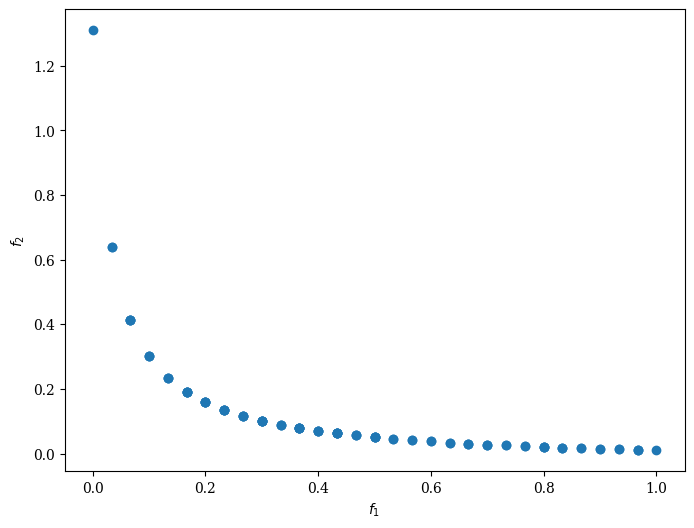

In [ ]:
w!pip install pymoo
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.bitflip import BitflipMutation
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

problem = get_problem("zdt5")


algorithm = NSGA2(pop_size=100,
                  sampling=BinaryRandomSampling(),
                  crossover=TwoPointCrossover(),
                  mutation=BitflipMutation(),
                  eliminate_duplicates=True)

res = minimize(problem,
               algorithm,
               ('n_gen', 500),
               seed=1,
               verbose=False)

Scatter().add(res.F).show()